# Análisis de Cuota de Empleo PcD — GeoPeru 2026

Análisis de cumplimiento de la cuota del 5 % de empleo para Personas con
Discapacidad (PcD) en entidades públicas peruanas, cruzado con la
disponibilidad territorial de PcD en edad de trabajar (DPRIPD).

In [1]:
# ── Biblioteca estándar ───────────────────────────────────────────────────────
import io
import os
import math
import tempfile
import zipfile
from pathlib import Path

# ── Terceros: datos y cómputo ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import requests
from dbfread import DBF

# ── Terceros: visualización y cartografía ────────────────────────────────────
import contextily as ctx
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import FancyBboxPatch, Rectangle
from shapely.geometry import box
from shapely.ops import unary_union

matplotlib.use('module://matplotlib_inline.backend_inline')

## 1. Carga de datos

Descarga los archivos ZIP desde GeoPeru, extrae el `.dbf` interno de cada uno
y lo convierte en un `DataFrame`.

In [2]:
def _fix_encoding(df: pd.DataFrame) -> pd.DataFrame:
    """Re-decodifica columnas de texto de latin-1 a UTF-8.

    Los archivos .dbf del GeoPeru están en UTF-8 pero su cabecera
    declara latin-1, por lo que dbfread los lee incorrectamente.
    """
    str_cols = df.select_dtypes(include=['object']).columns
    for col in str_cols:
        df[col] = df[col].apply(
            lambda x: x.encode('latin-1').decode('utf-8') if isinstance(x, str) else x
        )
    return df


def dbf_bytes_to_df(data: bytes) -> pd.DataFrame:
    """Convierte bytes de un archivo .dbf en un DataFrame de pandas.

    Escribe los bytes en un archivo temporal en disco (requerido por
    dbfread) y aplica la corrección de encoding al resultado.

    Parameters
    ----------
    data:
        Contenido binario del archivo .dbf.

    Returns
    -------
    pd.DataFrame
        Tabla leída y con encoding corregido.
    """
    with tempfile.NamedTemporaryFile(suffix='.dbf', delete=False) as tmp:
        tmp.write(data)
        tmp_path = tmp.name

    try:
        table = DBF(tmp_path, encoding='latin-1')
        df = pd.DataFrame(iter(table))
    finally:
        os.unlink(tmp_path)

    return _fix_encoding(df)


def load_dbf_from_zip_url(url: str) -> pd.DataFrame:
    """Descarga un ZIP remoto y devuelve su primer .dbf como DataFrame.

    Parameters
    ----------
    url:
        URL pública del archivo ZIP que contiene exactamente un .dbf.

    Returns
    -------
    pd.DataFrame
        Tabla extraída del .dbf.

    Raises
    ------
    FileNotFoundError
        Si el ZIP no contiene ningún archivo con extensión .dbf.
    """
    response = requests.get(url, timeout=120)
    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
        dbf_names = [name for name in zf.namelist() if name.lower().endswith('.dbf')]
        if not dbf_names:
            raise FileNotFoundError(f'No se encontró ningún .dbf en: {url}')
        dbf_data = zf.read(dbf_names[0])

    return dbf_bytes_to_df(dbf_data)

In [3]:
# Fuentes de datos GeoPeru
# DFS — Cuota de empleo PCD en entidades públicas (ene–dic 2023)
# DPRIPD — Registro de PCD por grupo de edad y nivel de gravedad (set 2024)
DATASET_URLS: dict[str, str] = {
    # DFS: cuota de empleo
    'dfs_gob_reg':       'https://descargas.geoperu.gob.pe/20241217165654___1_Cuota_empleo_Gob_Reg_ene_dic_2023.zip',
    'dfs_mun_prov':      'https://descargas.geoperu.gob.pe/20241217165211___2_Cuota_empleo_Mun_Prov_ene_dic_2023.zip',
    'dfs_mun_dist':      'https://descargas.geoperu.gob.pe/20241217171041___3_Cuota_empleo_Mun_Dist_ene_dic_2023.zip',
    'dfs_otras_ent':     'https://descargas.geoperu.gob.pe/20241217172741___4_Cuota_empleo_Otras_Ent_ene_dic_2023.zip',
    # DPRIPD: por grupo de edad
    'grupo_edad':        'https://descargas.geoperu.gob.pe/20241118182047___2_Por_Grupo_Edad_Set2024.zip',
    # DPRIPD: por nivel de gravedad
    'gravedad_leve':     'https://descargas.geoperu.gob.pe/20241120181004___4_Por_Nivel_Gravedad_Leve_Set2024.zip',
    'gravedad_moderado': 'https://descargas.geoperu.gob.pe/20241120181104___4_Por_Nivel_Gravedad_Moderado_Set2024.zip',
    'gravedad_severo':   'https://descargas.geoperu.gob.pe/20241120181225___4_Por_Nivel_Gravedad_Severo_Set2024.zip',
    'gravedad_no_esp':   'https://descargas.geoperu.gob.pe/20241120181415___4_Por_Nivel_Gravedad_No_Esp_Set2024.zip',
}

dataframes: dict[str, pd.DataFrame] = {}

for nombre, url in DATASET_URLS.items():
    print(f'  Descargando {nombre} ...', end=' ', flush=True)
    df = load_dbf_from_zip_url(url)
    dataframes[nombre] = df
    print(f'{df.shape[0]:>5} filas × {df.shape[1]:>2} cols')

# Alias de acceso directo
dfs_gob_reg     = dataframes['dfs_gob_reg']
dfs_mun_prov    = dataframes['dfs_mun_prov']
dfs_mun_dist    = dataframes['dfs_mun_dist']
dfs_otras_ent   = dataframes['dfs_otras_ent']
grupo_edad      = dataframes['grupo_edad']
gravedad_leve   = dataframes['gravedad_leve']
gravedad_mod    = dataframes['gravedad_moderado']
gravedad_sev    = dataframes['gravedad_severo']
gravedad_no_esp = dataframes['gravedad_no_esp']

# Vista rápida de la tabla principal y columnas disponibles
print('\n--- Vista previa: dfs_gob_reg ---')
print(dfs_gob_reg.head())

print('\n--- Columnas disponibles: grupo_edad ---')
print(list(grupo_edad.columns))

  Descargando dfs_gob_reg ...    21 filas × 40 cols
  Descargando dfs_mun_prov ...    95 filas × 40 cols
  Descargando dfs_mun_dist ...    11 filas × 40 cols
  Descargando dfs_otras_ent ...    16 filas × 40 cols
  Descargando grupo_edad ...  1858 filas × 34 cols
  Descargando gravedad_leve ...  1858 filas × 28 cols
  Descargando gravedad_moderado ...  1858 filas × 28 cols
  Descargando gravedad_severo ...  1858 filas × 28 cols
  Descargando gravedad_no_esp ...  1858 filas × 28 cols

--- Vista previa: dfs_gob_reg ---
   OBJECTID_1  NUM    REGION          CLA_ENTID  TOT_TRAB  TOT_PCD  P_CUMPLIM  \
0           1   12  Apurímac  Gobierno Regional      1884        8       0.42   
1          11   65       Ica  Gobierno Regional       387        6       1.55   
2          13  122  Moquegua  Gobierno Regional      1010        5       0.50   
3          18  133      Puno  Gobierno Regional      2616        2       0.08   
4          25   44     Cusco  Gobierno Regional      4180       89       

## 2. Transformación y cruce de tablas

Construye la tabla base `resultado` combinando la PEA de PcD por distrito
(extraída de `grupo_edad`) con los recuentos por nivel de gravedad.

In [4]:
# Columnas geográficas compartidas por todas las tablas
GEO_COLS = ['UBIGEO', 'COD_DPTO', 'NOM_DPTO', 'COD_PROV', 'NOM_PROV', 'COD_DIST', 'NOM_DIST']

# PCD en edad de trabajar (18–59 años) por centro poblado
pea = grupo_edad[GEO_COLS + ['AN_18_29', 'AN_30_44', 'AN_45_59']].copy()
pea['PCD_PEA'] = pea['AN_18_29'] + pea['AN_30_44'] + pea['AN_45_59']
pea = pea[GEO_COLS + ['PCD_PEA']]

# Extraer recuento por nivel de gravedad (una columna por nivel)
nivel_no_esp  = gravedad_no_esp[['UBIGEO', 'NO_ESPECI']].rename(columns={'NO_ESPECI': 'L0'})
nivel_leve    = gravedad_leve[['UBIGEO', 'LEVE']].rename(columns={'LEVE': 'L1'})
nivel_mod     = gravedad_mod[['UBIGEO', 'MODERADO']].rename(columns={'MODERADO': 'L2'})
nivel_sev     = gravedad_sev[['UBIGEO', 'SEVERO']].rename(columns={'SEVERO': 'L3'})

# Unir todos los niveles sobre la base de PEA
resultado = (
    pea
    .merge(nivel_no_esp, on='UBIGEO', how='left')
    .merge(nivel_leve,   on='UBIGEO', how='left')
    .merge(nivel_mod,    on='UBIGEO', how='left')
    .merge(nivel_sev,    on='UBIGEO', how='left')
)

# Reordenar columnas para legibilidad
resultado = resultado[
    ['COD_DPTO', 'NOM_DPTO', 'COD_PROV', 'NOM_PROV',
     'COD_DIST', 'NOM_DIST', 'PCD_PEA', 'L0', 'L1', 'L2', 'L3']
]

# PEA empleable de nivel leve/moderado, ponderada por su proporción en el total
total_por_nivel = resultado[['L0', 'L1', 'L2', 'L3']].sum(axis=1)
resultado['PCD_PEA_L1L2'] = (
    resultado['PCD_PEA'] * (resultado['L1'] + resultado['L2']) / total_por_nivel
).round().astype('Int64')

## 3. Consolidación de entidades públicas

Combina las cuatro fuentes DFS en una única tabla y calcula el déficit de PcD
respecto a la cuota legal del 5 %.

In [5]:
# Unión de los cuatro subconjuntos de entidades públicas
dfs_combined = pd.concat(
    [dfs_gob_reg, dfs_mun_prov, dfs_mun_dist, dfs_otras_ent],
    ignore_index=True,
)

dfs_combined = dfs_combined[[
    'ENTIDAD_I', 'TOT_TRAB', 'TOT_PCD',
    'COD_DPTO', 'NOM_DPTO', 'COD_PROV', 'NOM_PROV',
    'COD_DIST', 'NOM_DIST', 'LONGITUD', 'LATITUD',
]].copy()

# PCD que faltan para alcanzar la cuota del 5 % (Ley 29973)
dfs_combined['FALT_PCD'] = (
    np.ceil(
        ((0.05 - dfs_combined['TOT_PCD'] / dfs_combined['TOT_TRAB'])
         * dfs_combined['TOT_TRAB'])
        .clip(lower=0)
    )
    .astype('Int64')
)

## 4. Tabla final con índices

Cruza la oferta distrital de PcD con el déficit de cada entidad y calcula los
tres índices analíticos.

In [6]:
GEO_DIST_COLS = ['COD_DPTO', 'NOM_DPTO', 'COD_PROV', 'NOM_PROV', 'COD_DIST', 'NOM_DIST']

# PCD_PEA_L1L2 agregada al nivel de distrito (suma de todos los centros poblados)
pcd_por_distrito = resultado.groupby(GEO_DIST_COLS, as_index=False)[['PCD_PEA_L1L2']].sum()

# Unir oferta distrital con el dataset de entidades
final = dfs_combined.merge(pcd_por_distrito, on=GEO_DIST_COLS, how='left')

# ── Índices ───────────────────────────────────────────────────────────────────

# Proporción de la cuota cubierta (acotada a 1 cuando se supera el 5 %)
final['IDX_COBERTURA'] = (
    (final['TOT_PCD'] / (0.05 * final['TOT_TRAB']))
    .clip(upper=1)
    .round(3)
)

# Fracción de la demanda de PCD que puede cubrirse con la oferta distrital
final['IDX_VIABILIDAD'] = (
    1 - (final['FALT_PCD'] / final['PCD_PEA_L1L2']).clip(upper=1)
).round(3)

# Prioridad de intervención: mayor cuando hay incumplimiento Y alta oferta
final['IDX_PRIORIDAD'] = (
    (1 - final['IDX_COBERTURA']) * final['IDX_VIABILIDAD']
).round(3)

In [7]:
pd.set_option('display.max_rows', None)
final.sort_values('IDX_PRIORIDAD', ascending=False)

,ENTIDAD_I,TOT_TRAB,TOT_PCD,COD_DPTO,NOM_DPTO,COD_PROV,NOM_PROV,COD_DIST,NOM_DIST,LONGITUD,LATITUD,FALT_PCD,PCD_PEA_L1L2,IDX_COBERTURA,IDX_VIABILIDAD,IDX_PRIORIDAD
100,Municipalidad Provincial de Alto Amazonas,136,0,16,LORETO,1602,ALTO AMAZONAS,160201,YURIMAGUAS,-76.104191,-5.895408,7,263,0.000,0.973,0.973
64,Municipalidad Provincial de Dos de Mayo,27,0,10,HUANUCO,1003,DOS DE MAYO,100301,LA UNION,-76.801181,-9.828134,2,61,0.000,0.967,0.967
36,Municipalidad Provincial de Huancane,58,0,21,PUNO,2106,HUANCANE,210601,HUANCANE,-69.761914,-15.204041,3,85,0.000,0.965,0.965
121,Municipalidad Distrital de San Bernardino,20,0,06,CAJAMARCA,0612,SAN PABLO,061202,SAN BERNARDINO,-78.828065,-7.165877,1,26,0.000,0.962,0.962
93,Municipalidad Provincial de Pomabamba,75,0,02,ANCASH,0216,POMABAMBA,021601,POMABAMBA,-77.460522,-8.820923,4,88,0.000,0.955,0.955
23,Municipalidad Provincial de Huancasancos,38,0,05,AYACUCHO,0503,HUANCA SANCOS,050301,SANCOS,-74.334550,-13.920196,2,43,0.000,0.953,0.953
139,Hospital de San Juan de Lurigancho,1297,2,15,LIMA,1501,LIMA,150132,SAN JUAN DE LURIGANCHO,-77.003502,-11.966355,63,2382,0.031,0.974,0.944
25,Municipalidad Provincial de Vilcashuaman,46,0,05,AYACUCHO,0511,VILCAS HUAMAN,051101,VILCAS HUAMAN,-73.954016,-13.652591,3,49,0.000,0.939,0.939
99,Municipalidad Provincial de Datem del Marañon,33,0,16,LORETO,1607,DATEM DEL MARAÑON,160701,BARRANCA,-76.554960,-4.831126,2,27,0.000,0.926,0.926
137,Hospital Hermilio Valdizan,618,1,15,LIMA,1501,LIMA,150137,SANTA ANITA,-76.945685,-12.046397,30,532,0.032,0.944,0.914


## 5. Mapas de indicadores

Genera un mapa coroplético por cada índice con un recuadro de detalle para
Lima Metropolitana.

In [8]:
OUTPUT_DIR = Path('img')
OUTPUT_DIR.mkdir(exist_ok=True)

# Polígono de Perú en Web Mercator (EPSG:3857)
world = gpd.read_file('https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip')
peru_shape = unary_union(
    world[world['NAME'] == 'Peru'].to_crs(epsg=3857).geometry.buffer(0)
)

# Máscara de tierra exterior a Perú (para opacar países vecinos)
land_shape = unary_union(
    gpd.read_file('https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip')
    .to_crs(epsg=3857)
    .geometry.buffer(0)
)
extent_box = box(-9_500_000, -2_100_000, -7_000_000, 200_000)
mask_shape = extent_box.intersection(land_shape).difference(peru_shape)

mask_gdf = gpd.GeoDataFrame(geometry=[mask_shape], crs='EPSG:3857')
peru_gdf = gpd.GeoDataFrame(geometry=[peru_shape], crs='EPSG:3857')

# GeoDataFrame de entidades con coordenadas válidas
valid_cols = ['LATITUD', 'LONGITUD', 'IDX_COBERTURA', 'IDX_VIABILIDAD', 'IDX_PRIORIDAD']
gdf = gpd.GeoDataFrame(
    final.dropna(subset=valid_cols),
    geometry=gpd.points_from_xy(final['LONGITUD'], final['LATITUD']),
    crs='EPSG:4326',
).to_crs(epsg=3857)

# Subconjunto Lima Metropolitana
lima_gdf = gdf[gdf['NOM_DPTO'].str.upper() == 'LIMA']

# Límites del recuadro de Lima (Web Mercator)
LIMA_BOUNDS = {
    'minx': -8_585_000, 'maxx': -8_560_000,
    'miny': -1_380_000, 'maxy': -1_335_000,
}
ACCENT_COLOR = '#000000'

# Tamaño de marcadores proporcional al déficit de PCD
size_main = (final['FALT_PCD'] / final['FALT_PCD'].max() * 200 + 30).fillna(30)
size_lima = size_main[lima_gdf.index] * 2

n_total_georef = len(final.dropna(subset=['LATITUD', 'LONGITUD']))

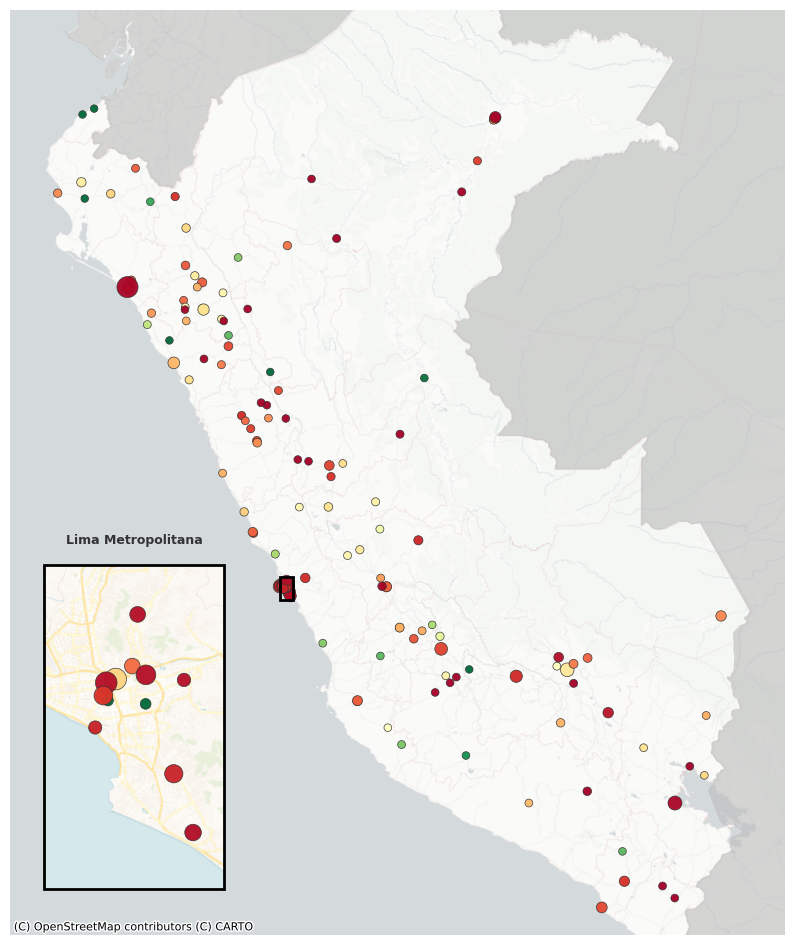

✓ img\mapa_IDX_COBERTURA.png guardado


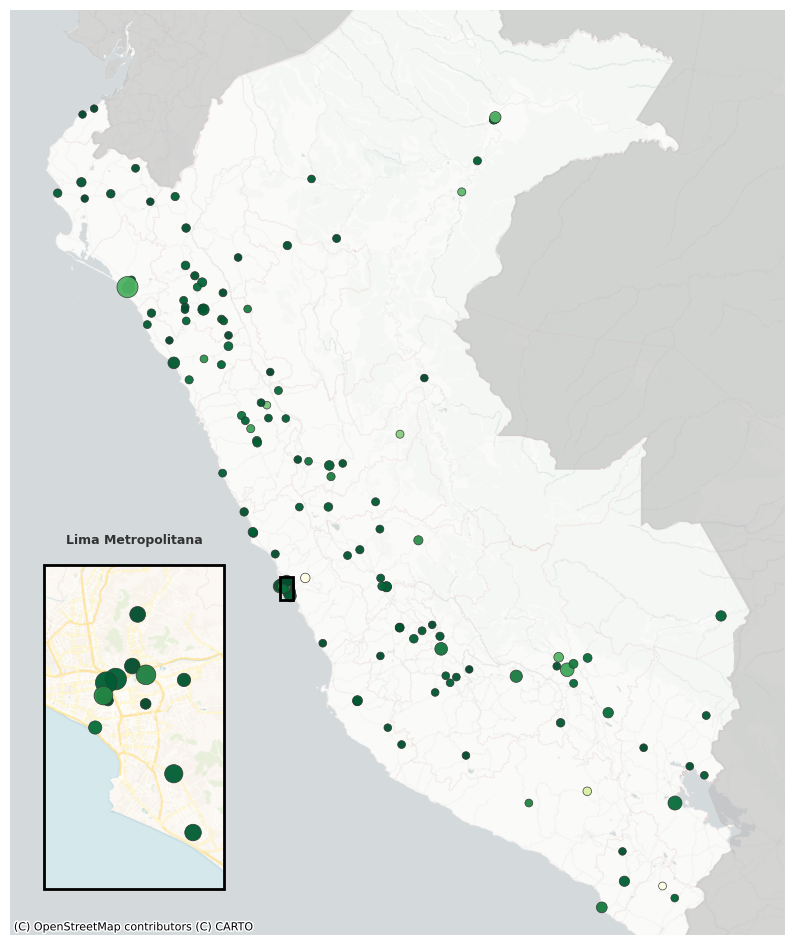

✓ img\mapa_IDX_VIABILIDAD.png guardado


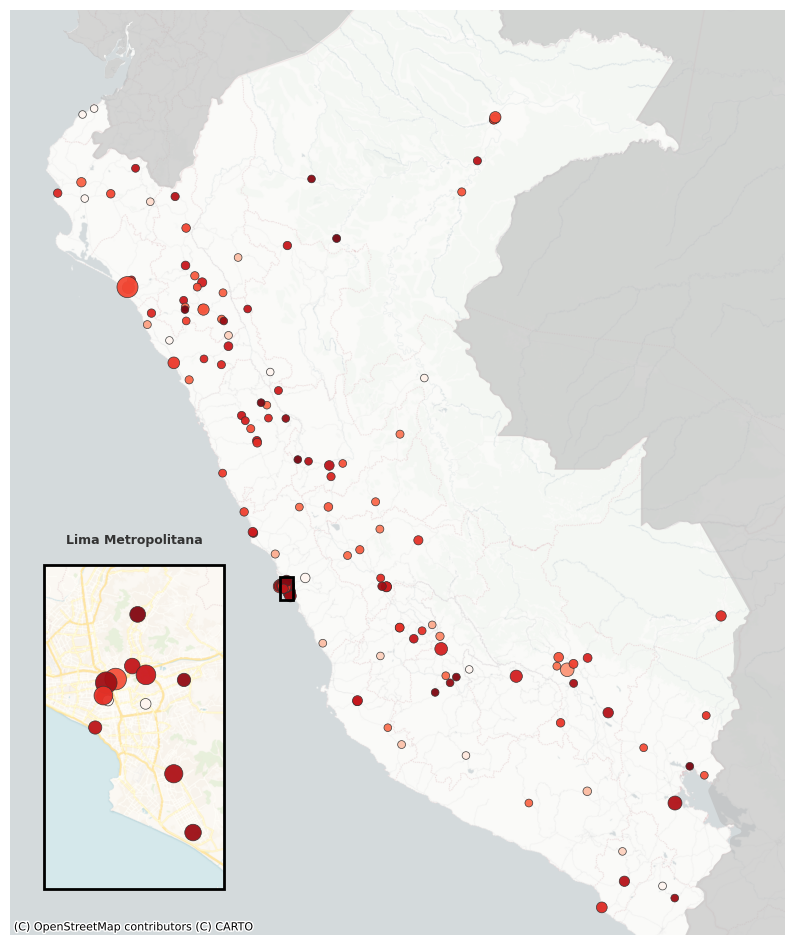

✓ img\mapa_IDX_PRIORIDAD.png guardado


In [9]:
# Definición de cada panel: (columna, cmap, etiqueta_min, etiqueta_max)
MAP_CONFIGS = [
    (
        'IDX_COBERTURA',
        '¿Cuánto de la cuota del 5% se está cumpliendo?',
        f'Ley 29973 — {n_total_georef} entidades públicas evaluadas',
        'RdYlGn',
        '0%  de la cuota',
        '100% de la cuota',
    ),
    (
        'IDX_VIABILIDAD',
        '¿Dónde hay PCD en edad de trabajar?',
        'Disponibilidad de PCD nivel leve/moderado en el distrito',
        'YlGn',
        'Sin oferta disponible',
        'Alta oferta disponible',
    ),
    (
        'IDX_PRIORIDAD',
        'Prioridad de intervención',
        'Entidades que incumplen la cuota Y tienen oferta PCD disponible',
        'Reds',
        'Baja prioridad',
        'Alta prioridad',
    ),
]

for col, titulo, subtitulo, cmap, label_min, label_max in MAP_CONFIGS:

    fig, ax = plt.subplots(figsize=(10, 14))

    # Fondo interior de Perú
    peru_gdf.plot(ax=ax, color='#f5f5f5', zorder=0)

    # Puntos coloreados por índice
    gdf.plot(
        ax=ax, column=col, cmap=cmap,
        markersize=size_main, alpha=0.95,
        vmin=0, vmax=1, zorder=3,
        edgecolor='#333333', linewidth=0.5,
    )

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=7)

    # Máscara exterior (países vecinos)
    mask_gdf.plot(ax=ax, color='#bbbbbb', alpha=0.6, zorder=2)

    ax.set_ylim(bottom=-2_050_000, top=-200_000)
    ax.set_axis_off()

    # Recuadro de referencia para Lima
    ax.add_patch(Rectangle(
        (LIMA_BOUNDS['minx'], LIMA_BOUNDS['miny']),
        LIMA_BOUNDS['maxx'] - LIMA_BOUNDS['minx'],
        LIMA_BOUNDS['maxy'] - LIMA_BOUNDS['miny'],
        linewidth=2, edgecolor=ACCENT_COLOR, facecolor='none',
        zorder=5, transform=ax.transData,
    ))

    # Inset de Lima Metropolitana
    ax_ins = inset_axes(
        ax, width='42%', height='35%', loc='lower left',
        bbox_to_anchor=(-0.05, 0.05, 1, 1),
        bbox_transform=ax.transAxes, borderpad=0,
    )

    lima_gdf.plot(
        ax=ax_ins, column=col, cmap=cmap,
        markersize=size_lima, alpha=0.95,
        vmin=0, vmax=1, zorder=3,
        edgecolor='#333333', linewidth=0.5,
    )

    ax_ins.set_xlim(LIMA_BOUNDS['minx'], LIMA_BOUNDS['maxx'])
    ax_ins.set_ylim(LIMA_BOUNDS['miny'], LIMA_BOUNDS['maxy'])

    try:
        ctx.add_basemap(ax_ins, source=ctx.providers.CartoDB.VoyagerNoLabels, zoom=11)
        for txt in ax_ins.texts:
            txt.set_visible(False)
    except Exception as exc:
        print(f'Basemap del inset no cargó: {exc}')
        ax_ins.set_facecolor('#e8e8e8')

    ax_ins.set_axis_off()
    ax_ins.set_title('Lima Metropolitana', fontsize=9, pad=4, color='#333', fontweight='bold')
    ax_ins.add_patch(FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle='square,pad=0',
        linewidth=2, edgecolor=ACCENT_COLOR, facecolor='none',
        transform=ax_ins.transAxes, zorder=10, clip_on=False,
    ))

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    output_path = OUTPUT_DIR / f'mapa_{col}.png'
    plt.savefig(
        output_path, dpi=150, bbox_inches='tight',
        pad_inches=0, transparent=True, facecolor='none', edgecolor='none',
    )
    plt.show()
    plt.close()
    print(f'✓ {output_path} guardado')